# **4.0. Tree-Based Models**:
**Tree-based Pipeline**
> 4.1. **Train-Valid-Test Split** <br>
> 4.2. **Preprocessing for Tree-based Models**<br>
> 4.3. **Bayesian Optimization (BayesSearchCV)** <br>
> 4.4. **Modeling Pipeline** <br>

In [1]:
# Libraries
import pandas as pd
import numpy as np

# Logging
import logging
import time

# Scipy
from scipy.stats import ( 
    ks_2samp, spearmanr
)

# CPU Cores & System
import os
import sys
import psutil

if os.getcwd().endswith('notebooks'):
    %cd ..

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

# Tree-based Library
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

/home/gontommuhammad/credit_risk_modeling


In [2]:
from src.utils import deserialize_data

# Train Set:
X_train = deserialize_data('data/interim/X_train_raw.pkl')
y_train = deserialize_data('data/interim/y_train.pkl')

# Validation Set
X_valid = deserialize_data('data/interim/X_valid_raw.pkl')
y_valid = deserialize_data('data/interim/y_valid.pkl')

# Test Set
X_test = deserialize_data('data/interim/X_test_raw.pkl')
y_test = deserialize_data('data/interim//y_test.pkl')

Data successfully deserialized from data/interim/X_train_raw.pkl
Data successfully deserialized from data/interim/y_train.pkl
Data successfully deserialized from data/interim/X_valid_raw.pkl
Data successfully deserialized from data/interim/y_valid.pkl
Data successfully deserialized from data/interim/X_test_raw.pkl
Data successfully deserialized from data/interim//y_test.pkl


<br>

---
## **4.1. Train-Valid-Test Split**:

In [3]:
from src.utils import split_train_test

# ============================================================
# SPLIT TRAIN -> TRAIN_FIT + TRAIN_ES + TRAIN_CAL
# ============================================================
# Third split proportions INSIDE original train for Tree-based
# Step 1: take 30% from X_train -> X_temp
# Step 2: split X_temp equally -> train_es: 7.5%, train_cal: 7.5%

RANDOM_STATE = 42
TRAIN_TEMP_SIZE = 0.15
ES_CAL_SHARE_WITHIN_TEMP = 0.50   # => 7.5% of original train / ES = Early Stopping & CAL = Calibrated

print(f"Step 3: Splitting original `X_train` into `X_train_fit` + `X_temp`")
X_train_fit, X_temp_ec, y_train_fit, y_temp_ec = split_train_test(
    X_train,
    y_train,
    test_size=TRAIN_TEMP_SIZE,
    stratify=y_train,
    seed=RANDOM_STATE
)

print(f"Step 4: Splitting `X_temp` into `X_train_es` + `X_train_cal`")
X_train_es, X_train_cal, y_train_es, y_train_cal = split_train_test(
    X_temp_ec,
    y_temp_ec,
    test_size=ES_CAL_SHARE_WITHIN_TEMP,
    stratify=y_temp_ec,
    seed=RANDOM_STATE
)
print(f"-" * 54)
print(f"=== SPLIT DATA SNAPSHOT ===")
print(f"X_train_fit shape : {X_train_fit.shape}, y_train_fit  : {y_train_fit.shape} | Periode: {X_train_fit['issue_d'].min().date()} s/d {X_train_fit['issue_d'].max().date()}")
print(f"X_train_es  shape : {X_train_es.shape},  y_train_es   : {y_train_es.shape}  | Periode: {X_train_es['issue_d'].min().date()} s/d {X_train_es['issue_d'].max().date()}")
print(f"X_train_cal shape : {X_train_cal.shape},  y_train_cal  : {y_train_cal.shape}  | Periode: {X_train_cal['issue_d'].min().date()} s/d {X_train_cal['issue_d'].max().date()}")
print(f"X_valid     shape : {X_valid.shape}, y_valid      : {y_valid.shape} | Periode: {X_valid['issue_d'].min().date()} s/d {X_valid['issue_d'].max().date()}")
print(f"X_test      shape : {X_test.shape}, y_test       : {y_test.shape} | Periode: {X_test['issue_d'].min().date()} s/d {X_test['issue_d'].max().date()} (OOT)")

Step 3: Splitting original `X_train` into `X_train_fit` + `X_temp`
Step 4: Splitting `X_temp` into `X_train_es` + `X_train_cal`
------------------------------------------------------
=== SPLIT DATA SNAPSHOT ===
X_train_fit shape : (72049, 18), y_train_fit  : (72049,) | Periode: 2007-08-01 s/d 2012-12-01
X_train_es  shape : (6357, 18),  y_train_es   : (6357,)  | Periode: 2007-09-01 s/d 2012-12-01
X_train_cal shape : (6358, 18),  y_train_cal  : (6358,)  | Periode: 2007-08-01 s/d 2012-12-01
X_valid     shape : (10596, 18), y_valid      : (10596,) | Periode: 2007-08-01 s/d 2012-12-01
X_test      shape : (22481, 18), y_test       : (22481,) | Periode: 2013-01-01 s/d 2013-03-01 (OOT)


In [4]:
# Validate
print(len(X_train_fit)/len(X_train))  # should be 0.85
print(len(X_train_es)/len(X_train))   # should be 0.075
print(len(X_train_cal)/len(X_train))  # should be 0.075

0.8499952810155255
0.0749964607616441
0.07500825822283044


In [5]:
print(f"y_train_fit : {y_train_fit.value_counts()}")
print(f"y_train_es  : {y_train_es.value_counts()}")
print(f"y_train_cal : {y_train_cal.value_counts()}")
print(f"y_valid     : {y_valid.value_counts()}")
print(f"y_test      : {y_test.value_counts()}")

y_train_fit : target
0    61069
1    10980
Name: count, dtype: int64
y_train_es  : target
0    5388
1     969
Name: count, dtype: int64
y_train_cal : target
0    5389
1     969
Name: count, dtype: int64
y_valid     : target
0    8981
1    1615
Name: count, dtype: int64
y_test      : target
0    19346
1     3135
Name: count, dtype: int64


In [6]:
X_train_fit.info()

<class 'pandas.DataFrame'>
Index: 72049 entries, 1706340 to 1055414
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   annual_inc                  72049 non-null  float64       
 1   collections_12_mths_ex_med  72049 non-null  float64       
 2   delinq_2yrs                 72049 non-null  float64       
 3   dti                         72049 non-null  float64       
 4   earliest_cr_line            72049 non-null  datetime64[us]
 5   emp_length                  69777 non-null  str           
 6   home_ownership              72049 non-null  str           
 7   inq_last_6mths              72049 non-null  float64       
 8   issue_d                     72049 non-null  datetime64[us]
 9   loan_amnt                   72049 non-null  int64         
 10  open_acc                    72049 non-null  float64       
 11  pub_rec                     72049 non-null  float64       
 12

<br>

---
## **4.2. Preprocessing for Tree-based Models:**

In [7]:
# Import functions and classes from the binning module
from src.binning_woe import (
    add_derived_features
)

X_train_fit = add_derived_features(X_train_fit)
X_train_es  = add_derived_features(X_train_es)
X_train_cal = add_derived_features(X_train_cal)
X_valid     = add_derived_features(X_valid)
X_test      = add_derived_features(X_test)

# Sorted Columns
X_train_fit = X_train_fit[sorted(X_train_fit.columns)]
X_train_es  = X_train_es[sorted(X_train_es.columns)]
X_train_cal = X_train_cal[sorted(X_train_cal.columns)]
X_valid     = X_valid[sorted(X_valid.columns)]
X_test      = X_test[sorted(X_test.columns)]

X_train_fit.info()

(CVXPY) Jul 19 05:02:47 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/home/gontommuhammad/miniconda3/envs/credit-risk_VENV/lib/python3.13/site-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


<class 'pandas.DataFrame'>
Index: 72049 entries, 1706340 to 1055414
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   annual_inc          72049 non-null  float64 
 1   credit_age_years    72049 non-null  float64 
 2   dti                 72049 non-null  float64 
 3   emp_length_ordinal  69777 non-null  float64 
 4   has_derogatory      72049 non-null  category
 5   home_ownership      72049 non-null  category
 6   inq_last_6mths      72049 non-null  float64 
 7   loan_to_income      72049 non-null  float64 
 8   open_acc_ratio      72049 non-null  float64 
 9   purpose             72049 non-null  category
 10  revol_util          72049 non-null  float64 
 11  term                72049 non-null  category
dtypes: category(4), float64(8)
memory usage: 5.2 MB


In [8]:
import math
from collections import Counter

# Function to calculate entropy
def entropy(labels):
    label_counts = Counter(labels)
    total_elements = len(labels)
    entropy = 0.0
    for label in label_counts:
        prob_of_label = label_counts[label] / total_elements
        entropy -= prob_of_label * math.log2(prob_of_label)
    return round(entropy, 4)

# Function to calculate weighted entropy for a split
def entropy_for_split(data, feature, target):
    unique_values = data[feature].unique()
    total_instances = len(data)
    weighted_entropy = 0.0
    for value in unique_values:
        subset = data[data[feature] == value][target]
        subset_entropy = entropy(subset)
        weighted_entropy += (len(subset) / total_instances) * subset_entropy
    return round(weighted_entropy, 4)

# Function to calculate information gain
def information_gain(data, feature, target):
    overall_entropy = entropy(data[target])
    weighted_entropy = entropy_for_split(data, feature, target)
    info_gain = overall_entropy - weighted_entropy
    return round(info_gain, 4)


# Calculate Information Gain for each feature
features = X_train_fit.columns.tolist()

# Target variable
target = 'y'

# Call the function and iterate features
info_gain_values = {feature: information_gain(X_train_fit.assign(y=y_train_fit), feature, target) for feature in features}

# Sort the features by Information Gain in descending order
sorted_info_gain_values = sorted(info_gain_values.items(), key=lambda item: item[1], reverse=True)

# Print the best feature
best_feature, best_info_gain = sorted_info_gain_values[0]
print(f"Best Feature to choose as Root Node: {best_feature}")
print(f"With Information Gain: {best_info_gain}")

# Print Information Gain for all features
print(f'\nInformation Gain for each feature:')
for feature, gain in sorted_info_gain_values:
    print(f"{feature}: {gain}")

Best Feature to choose as Root Node: loan_to_income
With Information Gain: 0.1896

Information Gain for each feature:
loan_to_income: 0.1896
annual_inc: 0.0723
dti: 0.0426
emp_length_ordinal: 0.0235
revol_util: 0.0177
term: 0.0103
open_acc_ratio: 0.0096
credit_age_years: 0.0064
inq_last_6mths: 0.0057
purpose: 0.0049
has_derogatory: 0.0006
home_ownership: 0.0004


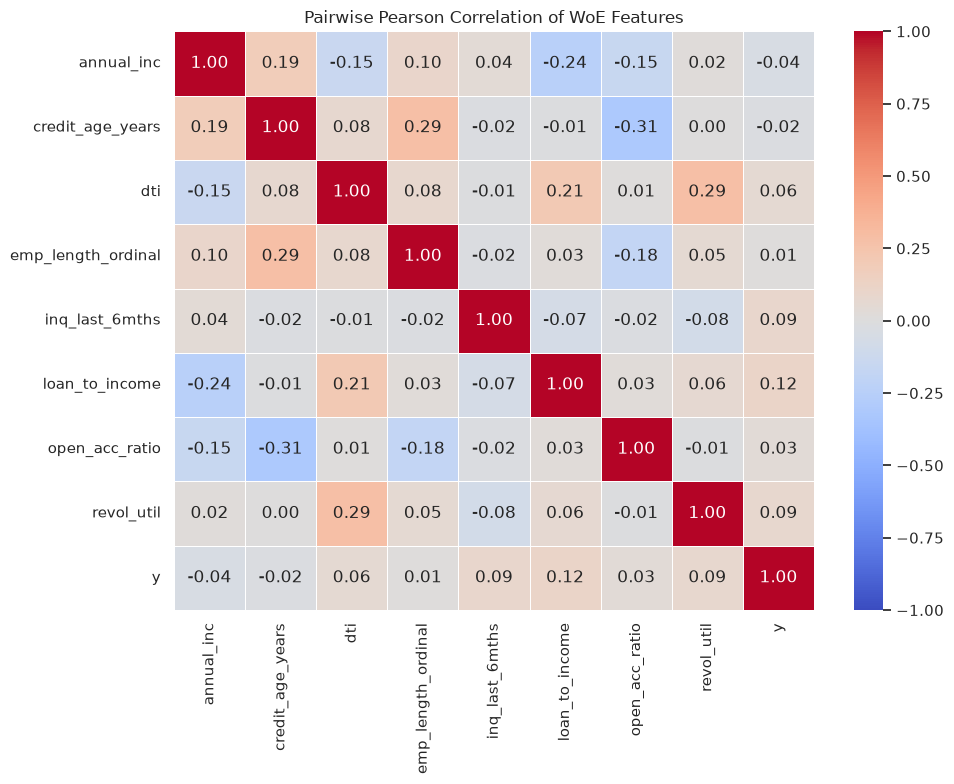

There are no feature pairs with correlation >= 0.5


In [9]:
df_corr = X_train_fit.select_dtypes(include=[np.number])

# 1. Calculate Pairwise Pearson Correlation
corr_matrix = df_corr.assign(y=y_train_fit).corr(method='pearson')

# 2. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)
plt.title(f"Pairwise Pearson Correlation of WoE Features")
plt.tight_layout()
plt.show()

# 3. Look for Feature Pairs with High Correlation (Suspected Multicollinearity)
# The correlation threshold is usually 0.5 or 0.6 for credit risk models.
threshold = 0.5  

# Take the upper triangle of the correlation matrix so that there are no duplications (A-B and B-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if abs(val) >= threshold:
            high_corr_pairs.append({
                'Feature 1': row,
                'Feature 2': col,
                'Correlation': val
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values(by='Correlation', key=abs, ascending=False).reset_index(drop=True)
    print(f"=== FEATURE PAIRS WITH HIGH CORRELATION (SUSPECTS) ===")
    print(high_corr_df)
else:
    print(f"There are no feature pairs with correlation >= {threshold}")

In [10]:
from src.utils import compute_vif

compute_vif(dataframe=X_train_fit, target_col=None)

NaN/inf found, row will be dropped before VIF calculation.

           feature     VIF
             const 30.3566
        annual_inc  1.1416
  credit_age_years  1.2214
               dti  1.1712
emp_length_ordinal  1.1113
    inq_last_6mths  1.0141
    loan_to_income  1.1064
    open_acc_ratio  1.1335
        revol_util  1.1040


In [11]:
from src.utils import calculate_all_iv
tabel_iv = calculate_all_iv(dataframe=X_train_fit.assign(y=y_train_fit), target_col='y', num_bins=6)
tabel_iv

,Feature,Information Value (IV)
0,loan_to_income,0.093446
1,revol_util,0.059682
2,inq_last_6mths,0.039251
3,annual_inc,0.032036
4,dti,0.024441
5,open_acc_ratio,0.009015
6,credit_age_years,0.003285
7,emp_length_ordinal,0.001777


<br>

---
### **Import Metrics from Scikit Learn**:

In [12]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, log_loss, 
    matthews_corrcoef, classification_report, confusion_matrix, balanced_accuracy_score, 
    average_precision_score, brier_score_loss, precision_recall_curve, accuracy_score
)

<br>

---
## **4.3. Bayesian Optimization (BayesSearchCV)**:

In [13]:
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from skopt.space import Real, Integer, Categorical
from tqdm.auto import tqdm

<br>

### **XGBoost Hyperparameter Tuning**:

In [14]:
# # Search spaces with two subspace
# depthwise_space = {
#     # learning dynamics
#     'learning_rate': Real(0.01, 0.12, prior='log-uniform'),
#     'max_depth': Integer(3, 8),
#     'min_child_weight': Real(0.5, 20.0, prior='log-uniform'),
#     'gamma': Real(1e-8, 5.0, prior='log-uniform'),
    
#     # stochastic regularization
#     'subsample': Real(0.65, 1.0),
#     'colsample_bytree': Real(0.60, 1.0),

#     # L1/L2 regularization
#     'reg_alpha': Real(1e-8, 100.0, prior='log-uniform'),
#     'reg_lambda': Real(1e-8, 50.0, prior='log-uniform'),

#     # probability stabilization for imbalance
#     'max_delta_step': Integer(0, 5),

#     # histogram-specific
#     'max_bin': Integer(128, 512),

#     # tree growth regime
#     'grow_policy': Categorical(['depthwise']),
# }

# lossguide_space = {
#     # learning dynamics
#     'learning_rate': Real(0.01, 0.10, prior='log-uniform'),
#     'max_depth': Integer(2, 6), 
#     'min_child_weight': Real(0.5, 20.0, prior='log-uniform'),
#     'gamma': Real(1e-8, 5.0, prior='log-uniform'),

#     # stochastic regularization
#     'subsample': Real(0.65, 1.0),
#     'colsample_bytree': Real(0.60, 1.0),

#     # L1/L2 regularization
#     'reg_alpha': Real(1e-8, 100.0, prior='log-uniform'),
#     'reg_lambda': Real(1e-8, 50.0, prior='log-uniform'),

#     # probability stabilization for imbalance
#     'max_delta_step': Integer(0, 5),

#     # histogram-specific
#     'max_bin': Integer(128, 512),

#     # lossguide-specific
#     'grow_policy': Categorical(['lossguide']),
#     'max_leaves': Integer(16, 256),
# }

# param_space = [
#     (depthwise_space, 60),
#     (lossguide_space, 60),
# ]

# # Estimator for tuning
# xgb_estimator = XGBClassifier(
#         objective='binary:logistic',
#         booster='gbtree',
#         eval_metric='logloss',
#         tree_method='hist',
#         enable_categorical=True,
#         n_estimators=600, 
#         n_jobs=1,
#         random_state=RANDOM_STATE,
#     )

# # BayesSearchCV
# bayes_search = BayesSearchCV(
#     estimator=xgb_estimator,
#     search_spaces=param_space,
#     n_iter=120, 
#     cv=StratifiedKFold(
#         n_splits=6, 
#         shuffle=True, 
#         random_state=RANDOM_STATE
#     ),
#     scoring='neg_log_loss',
#     n_jobs=-1,
#     n_points=1,
#     random_state=RANDOM_STATE,
#     refit=True,
#     return_train_score=True,
#     verbose=0,
# )

# # Run BayesSearchCV
# # Setup Logging to file
# for handler in logging.root.handlers[:]:
#     logging.root.removeHandler(handler)

# logging.basicConfig(
#     level=logging.INFO, 
#     filename='bayes_search.log', 
#     filemode='w', 
#     format='%(asctime)s - %(message)s'
# )

# # Custom Callback for Progress and Logging
# class TqdmProgressCallback:
#     def __init__(self, total_iter):
#         self.total_iter = total_iter
#         self.current_iter = 0
#         self.pbar = tqdm(
#             total=total_iter, 
#             desc="BayesSearch Iterations", 
#             unit="iter"
#         )
#         self.logger = logging.getLogger()
        
#     def __call__(self, result):
#         # Global iteration counter
#         self.current_iter += 1
        
#         # Using logging.getLogger() directly inside the scope is safer to avoid pickling the global variable 'logger'
#         self.logger.info(
#             f"Iteration {self.current_iter}/{self.total_iter}: "
#             f"Parameters {result.x}, "
#             f"Score {result.fun}"
#         )
        
#         # Update progress bar
#         self.pbar.update(1)

#         # Continue optimization
#         return False

#     def close(self):
#         self.pbar.close()

#     # --- Prevent PicklingError ---
#     def __getstate__(self):
#         # When it is going to be pickled to the worker,
#         # we remove 'pbar' from the state that is sent
#         state = self.__dict__.copy()
#         state.pop("pbar", None)
#         return state

#     def __setstate__(self, state):
#         # When received by the worker (unpickled), set pbar to `None`
#         self.__dict__.update(state)
#         self.pbar = None

# # Initialize progress callback
# progress_callback = TqdmProgressCallback(
#     total_iter=bayes_search.n_iter
# )
# # Attach callback to BayesSearchCV
# logging.getLogger().info(f"Starting BayesSearchCV...")
# bayes_search.fit(
#     X_train_fit,
#     y_train_fit,
#     callback=progress_callback
# )

# # Close progress bar
# progress_callback.close()

# # Showing the best parameters
# best_params = bayes_search.best_params_
# print(f"Best parameters:", best_params)

```python
OrderedDict([('colsample_bytree', 0.6),
             ('gamma', 1e-08),
             ('grow_policy', 'depthwise'),
             ('learning_rate', 0.03338891831593357),
             ('max_bin', 128),
             ('max_delta_step', 5),
             ('max_depth', 3),
             ('min_child_weight', 17.529933739836622),
             ('reg_alpha', 1.2452040793530908e-06),
             ('reg_lambda', 1e-08),
             ('subsample', 0.689512440186034)])
```

```python
OrderedDict([('colsample_bytree', 0.6286729841272466),
             ('gamma', 4.999999999999999),
             ('grow_policy', 'depthwise'),
             ('learning_rate', 0.01783339959316753),
             ('max_bin', 507),
             ('max_delta_step', 0),
             ('max_depth', 8),
             ('min_child_weight', 20.0),
             ('reg_alpha', 1e-08),
             ('reg_lambda', 1e-08),
             ('subsample', 0.65)])

<br>

---
### **CatBoost Hyperparameter Tuning**:

In [15]:
CAT_FEATURES = X_train_fit.select_dtypes(
    include=['category']
).columns.tolist()

CAT_FEATURES

['has_derogatory', 'home_ownership', 'purpose', 'term']

In [16]:
# # ── Subspace 1: SymmetricTree ──────────────────────────────────────────────
# # CatBoost's default and most distinctive regime: oblivious trees enforce
# # a single split condition per depth level, providing strong implicit
# # regularization and O(depth) inference — well-suited to imbalanced credit risk.
# symmetric_space = {
#     # tree growth regime
#     "grow_policy": Categorical(["SymmetricTree"]),
#     # learning dynamics
#     "learning_rate":    Real(0.01, 0.12, prior="log-uniform"),
#     "depth":            Integer(4, 8),          # 2^d leaves; d=8 → 256 leaves
#     "min_data_in_leaf": Integer(1, 50),         # count-based (not hessian-sum)
#     # stochastic regularization (bootstrap_type="Bernoulli" locked on estimator)
#     "subsample":        Real(0.65, 1.0),
#     "rsm":              Real(0.60, 1.0),        # ≡ colsample_bytree
#     # L2 regularization (CatBoost has no L1 leaf-level equivalent)
#     "l2_leaf_reg":      Real(1e-3, 100.0, prior="log-uniform"),
#     # stochastic split-score noise: probabilistic analog of XGB's gamma
#     "random_strength":  Real(1e-9, 10.0, prior="log-uniform"),
#     # feature histogram resolution
#     "border_count":     Integer(64, 256),       # ≡ max_bin; default=254
# }

# # ── Subspace 2: Depthwise ─────────────────────────────────────────────────
# # Level-wise growth analogous to XGBoost's depthwise policy.
# # All nodes at the same depth level are grown before proceeding deeper.
# depthwise_space = {
#     # tree growth regime
#     "grow_policy":      Categorical(["Depthwise"]),
#     # learning dynamics
#     "learning_rate":    Real(0.01, 0.12, prior="log-uniform"),
#     "depth":            Integer(3, 8),
#     "min_data_in_leaf": Integer(1, 100),
#     # stochastic regularization
#     "subsample":        Real(0.65, 1.0),
#     "rsm":              Real(0.60, 1.0),
#     # L2 regularization
#     "l2_leaf_reg":      Real(1e-3, 100.0, prior="log-uniform"),
#     # stochastic split-score noise
#     "random_strength":  Real(1e-9, 10.0, prior="log-uniform"),
#     # feature histogram resolution
#     "border_count":     Integer(64, 256),
# }

# # ── Subspace 3: Lossguide ─────────────────────────────────────────────────
# # Leaf-wise (best-first) growth analogous to XGBoost's lossguide policy.
# # max_leaves controls tree complexity; depth acts as a hard per-leaf cap.
# # learning_rate upper bound slightly reduced: leaf-wise trees are more
# # expressive per iteration and thus more susceptible to overshooting.
# lossguide_space = {
#     # tree growth regime
#     "grow_policy":      Categorical(["Lossguide"]),
#     "max_leaves":       Integer(16, 256),       # primary complexity controller
#     # learning dynamics
#     "learning_rate":    Real(0.01, 0.10, prior="log-uniform"),
#     "depth":            Integer(2, 6),          # per-leaf depth cap
#     "min_data_in_leaf": Integer(1, 100),
#     # stochastic regularization
#     "subsample":        Real(0.65, 1.0),
#     "rsm":              Real(0.60, 1.0),
#     # L2 regularization
#     "l2_leaf_reg":      Real(1e-3, 100.0, prior="log-uniform"),
#     # stochastic split-score noise
#     "random_strength":  Real(1e-9, 10.0, prior="log-uniform"),
#     # feature histogram resolution
#     "border_count":     Integer(64, 256),
# }

# # ── Search Space Registry ──────────────────────────────────────────────────
# # Total: 120 iterations (40 per subspace), matching XGBoost budget.
# # Allocation is uniform: SymmetricTree and Lossguide are structurally
# # distinct enough to warrant equal exploration budget.
# param_space = [
#     (symmetric_space,  60),
#     (depthwise_space,  60),
#     (lossguide_space,  60),
# ]

# # ── Locked Estimator ───────────────────────────────────────────────────────
# catboost_estimator = CatBoostClassifier(
#     # objective and evaluation
#     loss_function='Logloss',        # ≡ objective="binary:logistic"
#     eval_metric='Logloss',          # consistent with scoring="neg_log_loss"
#     # tree budget (fixed; early stopping not applicable in BayesSearchCV CV loop)
#     iterations=500,                 # ≡ n_estimators=600
#     # bootstrap: MUST be locked to "Bernoulli" to activate subsample parameter;
#     # "Bayesian" mode uses bagging_temperature instead, creating a conditional
#     # dependency that cannot be represented cleanly in a single BayesSearchCV space
#     bootstrap_type='Bernoulli',
#     # hardware and reproducibility
#     task_type='CPU',
#     thread_count=1,                 # parallelism delegated to BayesSearchCV n_jobs=-1
#     random_seed=RANDOM_STATE,
#     verbose=0,
#     # auto_class_weights intentionally NOT set: preserves probability distribution
#     # for downstream calibration (consistent with XGBoost omitting scale_pos_weight)
# )

# # ── BayesSearchCV ──────────────────────────────────────────────────────────
# bayes_search = BayesSearchCV(
#     estimator=catboost_estimator,
#     search_spaces=param_space,
#     n_iter=180,
#     cv=StratifiedKFold(
#         n_splits=6,
#         shuffle=True,
#         random_state=RANDOM_STATE,
#     ),
#     scoring='neg_log_loss',
#     n_jobs=-1,
#     n_points=1,
#     random_state=RANDOM_STATE,
#     refit=True,
#     return_train_score=True,
#     verbose=0,
# )

# # Run BayesSearchCV
# # Setup Logging to file
# for handler in logging.root.handlers[:]:
#     logging.root.removeHandler(handler)
    
# logging.basicConfig(
#     level=logging.INFO, 
#     filename='bayes_search.log', 
#     filemode='w', 
#     format='%(asctime)s - %(message)s'
# )

# # Custom Callback for Progress and Logging
# class TqdmProgressCallback:
#     def __init__(self, total_iter):
#         self.total_iter = total_iter
#         self.current_iter = 0
#         self.pbar = tqdm(
#             total=total_iter, 
#             desc="BayesSearch Iterations", 
#             unit="iter"
#         )
#         self.logger = logging.getLogger()
        
#     def __call__(self, result):
#         # Global iteration counter
#         self.current_iter += 1
        
#         # Using logging.getLogger() directly inside the scope is safer to avoid pickling the global variable 'logger'
#         self.logger.info(
#             f"Iteration {self.current_iter}/{self.total_iter}: "
#             f"Parameters {result.x}, "
#             f"Score {result.fun}"
#         )
        
#         # Update progress bar
#         self.pbar.update(1)

#         # Continue optimization
#         return False

#     def close(self):
#         self.pbar.close()

#     # --- Prevent PicklingError ---
#     def __getstate__(self):
#         # When it is going to be pickled to the worker,
#         # we remove 'pbar' from the state that is sent
#         state = self.__dict__.copy()
#         state.pop("pbar", None)
#         return state

#     def __setstate__(self, state):
#         # When received by the worker (unpickled), set pbar to `None`
#         self.__dict__.update(state)
#         self.pbar = None
        

# # Initialize progress callback
# progress_callback = TqdmProgressCallback(
#     total_iter=bayes_search.n_iter
# )
# # Attach callback to BayesSearchCV
# logging.getLogger().info(f"Starting BayesSearchCV...")
# bayes_search.fit(
#     X_train_fit, 
#     y_train_fit,
#     callback=progress_callback,
#     cat_features=CAT_FEATURES
# )

# # Close progress bar
# progress_callback.close()

# # Showing the best parameters
# best_params = bayes_search.best_params_
# print(f"Best parameters:", best_params)

```python
OrderedDict([('border_count', 64),
             ('depth', 6),
             ('grow_policy', 'SymmetricTree'),
             ('l2_leaf_reg', 100.0),
             ('learning_rate', 0.034042376046732846),
             ('min_data_in_leaf', 45),
             ('random_strength', 1e-09),
             ('rsm', 0.6),
             ('subsample', 0.65)])
```

<br>

---
### **LGBM Hyperparameter Tuning**:

In [17]:
# # LightGBM search space: one subspace (default leaf-wise growth)
# lgbm_space = {
#     'learning_rate':      Real(0.01, 0.10, prior='log-uniform'),
#     'num_leaves':         Integer(16, 256),     # primary complexity controller
#     'max_depth':          Integer(3, 8),        # per-leaf depth cap
#     'min_child_samples':  Integer(5, 100),      # ≡ min_data_in_leaf CatBoost
#     # stochastic regularization
#     'subsample':          Real(0.65, 1.0),      # active because subsample_freq=1
#     'feature_fraction':   Real(0.60, 1.0),      # ≡ colsample_bytree / rsm
#     # L1 + L2 regularization (LGBM supports both)
#     'reg_alpha':          Real(1e-8, 100.0, prior='log-uniform'),  # L1
#     'reg_lambda':         Real(1e-8, 50.0, prior='log-uniform'),   # L2
#     # split threshold (≡ gamma XGBoost)
#     'min_split_gain':     Real(1e-8, 5.0, prior='log-uniform'),
#     # histogram resolution
#     'max_bin':            Integer(128, 512),
# }

# # ── LightGBM (model keempat) ───────────────────────────────────────────────
# lgbm_estimator = LGBMClassifier(
#     objective='binary',
#     metric='binary_logloss',
#     n_estimators=600,
#     subsample_freq=1,       # must be locked for subsample to be active
#     class_weight=None,
#     n_jobs=1,
#     random_state=RANDOM_STATE,
#     verbose=-1,
# )

# bayes_search = BayesSearchCV(
#     estimator=lgbm_estimator,
#     search_spaces=[(lgbm_space, 60)],
#     n_iter=60,
#     cv=StratifiedKFold(
#         n_splits=6, 
#         shuffle=True, 
#         random_state=RANDOM_STATE
#     ),
#     scoring='neg_log_loss',
#     n_jobs=-1,
#     n_points=1,
#     random_state=RANDOM_STATE,
#     refit=True,
#     return_train_score=True,
#     verbose=0,
# )

# # Run BayesSearchCV
# # Setup Logging to file
# for handler in logging.root.handlers[:]:
#     logging.root.removeHandler(handler)
    
# logging.basicConfig(
#     level=logging.INFO, 
#     filename='bayes_search.log', 
#     filemode='w', 
#     format='%(asctime)s - %(message)s'
# )

# # Custom Callback for Progress and Logging
# class TqdmProgressCallback:
#     def __init__(self, total_iter):
#         self.total_iter = total_iter
#         self.current_iter = 0
#         self.pbar = tqdm(
#             total=total_iter, 
#             desc="BayesSearch Iterations", 
#             unit="iter"
#         )
#         self.logger = logging.getLogger()
        
#     def __call__(self, result):
#         # Global iteration counter
#         self.current_iter += 1
        
#         # Using logging.getLogger() directly inside the scope is safer to avoid pickling the global variable 'logger'
#         self.logger.info(
#             f"Iteration {self.current_iter}/{self.total_iter}: "
#             f"Parameters {result.x}, "
#             f"Score {result.fun}"
#         )
        
#         # Update progress bar
#         self.pbar.update(1)

#         # Continue optimization
#         return False

#     def close(self):
#         self.pbar.close()

#     # --- Prevent PicklingError ---
#     def __getstate__(self):
#         # When it is going to be pickled to the worker,
#         # we remove 'pbar' from the state that is sent
#         state = self.__dict__.copy()
#         state.pop("pbar", None)
#         return state

#     def __setstate__(self, state):
#         # When received by the worker (unpickled), set pbar to `None`
#         self.__dict__.update(state)
#         self.pbar = None
        

# # Initialize progress callback
# progress_callback = TqdmProgressCallback(
#     total_iter=bayes_search.n_iter
# )
# # Attach callback to BayesSearchCV
# logging.getLogger().info(f"Starting BayesSearchCV...")
# bayes_search.fit(
#     X_train_fit, 
#     y_train_fit,
#     callback=progress_callback,
# )

# # Close progress bar
# progress_callback.close()

# # Showing the best parameters
# best_params = bayes_search.best_params_
# print(f"Best parameters:", best_params)

```python
OrderedDict([('feature_fraction', 0.986146700857756),
             ('learning_rate', 0.037340140218555355),
             ('max_bin', 216),
             ('max_depth', 3),
             ('min_child_samples', 46),
             ('min_split_gain', 0.3699480686014387),
             ('num_leaves', 95),
             ('reg_alpha', 5.820956912476788),
             ('reg_lambda', 49.99999999999999),
             ('subsample', 0.871939591996016)])
```

```python
OrderedDict([('feature_fraction', 0.6),
             ('learning_rate', 0.014752303267203249),
             ('max_bin', 512),
             ('max_depth', 6),
             ('min_child_samples', 72),
             ('min_split_gain', 5.524657351707396e-06),
             ('num_leaves', 16),
             ('reg_alpha', 0.46210107890864205),
             ('reg_lambda', 1.087620542758583e-08),
             ('subsample', 0.65)])
```

<br>

---
## **4.4. Modeling Pipeline**:

<br>

### **0─1. LOGGING & CONFIG**: 

In [18]:
# ============================================================
# 0. LOGGING
# ============================================================
logger = logging.getLogger("credit_risk_business_pipeline")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

# Formatter
formatter = logging.Formatter("%(asctime)s - %(levelname)s - %(message)s")

# Handler for files
file_handler = logging.FileHandler("credit_risk_business_pipeline.log", mode="w")
file_handler.setLevel(logging.INFO)
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

# Handler for Console (Terminal/Screen)
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

# ============================================================
# 1. CONFIG
# ============================================================

logger.info(f"========== START CREDIT RISK BUSINESS PIPELINE ==========")

# Threshold objective
THRESHOLD_OBJECTIVES = ['f1', 'youden', 'cost']

# Economic parameters:
c_fn = 8_250_000.0   # EAD * LGD = 15jt * 0.55
c_fp = 2_700_000.0   # EAD * spread * durasi = 15jt * 0.09 * 2


# XGB best params from BayesSearchCV
XGB_BEST_HYPERPARAMS = {
    'objective': 'binary:logistic',
    'booster': 'gbtree',
    'eval_metric': 'logloss',
    'tree_method': 'hist',
    'enable_categorical': True,
    'n_estimators': 5000,
    'early_stopping_rounds': 50,
    'learning_rate': 0.03338891831593357,
    'max_depth': 3,
    'min_child_weight': 20.0,
    'gamma': 1e-08,
    'subsample': 0.65,
    'colsample_bytree': 0.6,
    'reg_alpha': 1e-08,
    'reg_lambda': 1e-08,
    'max_delta_step': 0,
    'max_bin': 507,
    'grow_policy': 'depthwise',
    # 'max_leaves': 256,
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
}

# CatBoost based params
CAT_BEST_HYPERPARAMS = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'iterations': 5000,
    'early_stopping_rounds': 50,
    'bootstrap_type': 'Bernoulli',
    'cat_features': CAT_FEATURES,
    'task_type': 'CPU',
    'thread_count': -1,
    'border_count': 64,
    'learning_rate': 0.037340140218555355,
    'depth': 4,
    'grow_policy': 'SymmetricTree',
    'l2_leaf_reg': 100.0,
    'subsample': 0.65,
    'random_strength': 1e-09,
    'min_data_in_leaf': 45,
    'rsm': 0.6,
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
}

# LGBM best params from BayesSearchCV
LGBM_BEST_HYPERPARAMS = {
    # Objective
    'objective': 'binary',
    'metric': 'binary_logloss',

    # Boosting
    'boosting_type': 'gbdt',

    # Learning
    'n_estimators': 5000,
    'learning_rate': 0.037340140218555355,
    'early_stopping_rounds': 50,
    'feature_fraction': 0.6,

    # Tree complexity
    'max_depth': 3,
    'num_leaves': 16, 
    'min_child_samples': 72,

    # Sampling
    'subsample': 0.871939591996016,
    'subsample_freq': 1,
    'colsample_bytree': 0.60,

    # Regularization
    'reg_alpha': 5.820956912476788, 
    'reg_lambda': 49.99999999999999,
    'min_split_gain': 0.3699480686014387,

    # Histogram
    'max_bin': 512,

    # Misc
    'class_weight': None,
    'verbosity': -1,
    'n_jobs': -1,
    'random_state': RANDOM_STATE,
}

BLSMOTE_CONFIG = {
    'sampling_strategy': 'auto',
    'kind': 'borderline-1',
    'k_neighbors': 5,
    'm_neighbors': 10,
    'random_state': RANDOM_STATE
}

logger.info(f"RANDOM STATE = {RANDOM_STATE}")
logger.info(f"XGB BEST PARAMS = {XGB_BEST_HYPERPARAMS}")
logger.info(f"CAT BEST PARAMS = {CAT_BEST_HYPERPARAMS}")
logger.info(f"CAT FEATURES = {CAT_FEATURES}")
logger.info(f"LGBM BEST PARAMS = {LGBM_BEST_HYPERPARAMS}")
logger.info(f"BLSMOTE CONFIG = {BLSMOTE_CONFIG}")
logger.info(f"THRESHOLD_OBJECTIVES = {THRESHOLD_OBJECTIVES}")
logger.info(f"COST OF FALSE NEGATIVE = {c_fn}")
logger.info(f"COST OF FALSE POSITIVE = {c_fp}")
logger.info(f"========= TREE-BASED DATASET SNAPSHOT =========")
logger.info(f"=============== TRAINING SET ==================")
logger.info(f"train_fit          : X={X_train_fit.shape},  y={y_train_fit.shape}")
logger.info(f"train_es           : X={X_train_es.shape},   y={y_train_es.shape}")
logger.info(f"train_cal          : X={X_train_cal.shape},   y={y_train_cal.shape}")
logger.info(f"================ TEST SET =====================")
logger.info(f"valid              : X={X_valid.shape},   y={y_valid.shape}")
logger.info(f"test               : X={X_test.shape},   y={y_test.shape}")

2026-07-19 05:02:59,352 - INFO - ========== START CREDIT RISK BUSINESS PIPELINE ==========
2026-07-19 05:02:59,353 - INFO - RANDOM STATE = 42
2026-07-19 05:02:59,355 - INFO - XGB BEST PARAMS = {'objective': 'binary:logistic', 'booster': 'gbtree', 'eval_metric': 'logloss', 'tree_method': 'hist', 'enable_categorical': True, 'n_estimators': 5000, 'early_stopping_rounds': 50, 'learning_rate': 0.03338891831593357, 'max_depth': 3, 'min_child_weight': 20.0, 'gamma': 1e-08, 'subsample': 0.65, 'colsample_bytree': 0.6, 'reg_alpha': 1e-08, 'reg_lambda': 1e-08, 'max_delta_step': 0, 'max_bin': 507, 'grow_policy': 'depthwise', 'n_jobs': -1, 'random_state': 42}
2026-07-19 05:02:59,364 - INFO - CAT BEST PARAMS = {'loss_function': 'Logloss', 'eval_metric': 'Logloss', 'iterations': 5000, 'early_stopping_rounds': 50, 'bootstrap_type': 'Bernoulli', 'cat_features': ['has_derogatory', 'home_ownership', 'purpose', 'term'], 'task_type': 'CPU', 'thread_count': -1, 'border_count': 64, 'learning_rate': 0.0373401

<br>

### **Import Function**

In [19]:
from src.helpers import (
    build_candidate_registry,
    fit_all_candidate_models,
    evaluate_base_models_pipeline,
    select_stage_a_winner,
    run_probability_pipeline,
    evaluate_calibration_candidates, 
    should_calibrate, 
    evaluate_thresholds_pipeline, 
    threshold_classification_metrics,
    save_best_model,
    CALIBRATION_STRATEGIES,
)

<br>

### **2. FIT RAW OBJECT MODEL**:

In [20]:
logger.info(f"========== STAGE 0 - FIT ALL BASE MODELS ==========")
# Initialize Registry Model
# Inject model parameters into registry builder
model_registry = build_candidate_registry(
    xgb_params=XGB_BEST_HYPERPARAMS,
    cat_params=CAT_BEST_HYPERPARAMS,
    lgbm_params=LGBM_BEST_HYPERPARAMS,
    enable_blsmote=False
)
logger.info(f"========== CANDIDATE MODELS =======================")

candidate_overview = pd.DataFrame([
    {
        'model': model_name,
        'family': spec['family'],
        'use_blsmote': spec.get('use_blsmote', False),
        'estimator_class': spec['estimator'].__class__.__name__,
    }
    for model_name, spec in model_registry.items()
])
display(candidate_overview)

# Fit All Models at Once
# Run the training process for all candidate models
fitted_models_dict = fit_all_candidate_models(
    registry=model_registry,
    X_train_fit=X_train_fit,
    y_train_fit=y_train_fit,
    X_train_fit_blsmte=None,
    y_train_fit_blsmte=None,
    X_train_es=X_train_es,
    y_train_es=y_train_es
)
logger.info(f"All base models fitted successfully.")

# Setting up input parameters (Using dictionary)
my_fitted_models = {
    'xgb_raw': fitted_models_dict['xgb_raw'],
    'cat_raw': fitted_models_dict['cat_raw'],
    'lgbm_raw': fitted_models_dict['lgbm_raw'],
}

# Execute Pipeline Evaluation Phase A
base_model_leaderboard = evaluate_base_models_pipeline(
    fitted_models=my_fitted_models,
    X_train_fit=X_train_fit,
    y_train_fit=y_train_fit,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test
)

2026-07-19 05:02:59,502 - INFO - ========== STAGE 0 - FIT ALL BASE MODELS ==========
2026-07-19 05:02:59,506 - INFO - ========== CANDIDATE MODELS =======================


,model,family,use_blsmote,estimator_class
0,xgb_raw,xgb,False,XGBClassifier
1,cat_raw,cat,False,CatBoostClassifier
2,lgbm_raw,lgbm,False,LGBMClassifier


2026-07-19 05:03:14,463 - INFO - All base models fitted successfully.


In [21]:
# Display Leaderboard Results
# We sort by split and highest Gini/LogLoss performance in the validation data
display(
    base_model_leaderboard.sort_values(by=['split', 'roc_auc', 'ks_statistic',], ascending=[True, False, False,])
    .reset_index(drop=True)
)

,model_name,split,roc_auc,pr_auc,log_loss,brier_score,gini,ks_statistic
0,xgb_raw,1_train_fit,0.696634,0.297526,0.394355,0.120292,0.393269,0.285169
1,lgbm_raw,1_train_fit,0.693475,0.293208,0.395431,0.120626,0.386951,0.282265
2,cat_raw,1_train_fit,0.691341,0.295539,0.395882,0.120651,0.382682,0.276973
3,xgb_raw,2_valid,0.678778,0.270626,0.400156,0.122176,0.357555,0.266551
4,cat_raw,2_valid,0.678757,0.270421,0.400258,0.122214,0.357513,0.269500
5,lgbm_raw,2_valid,0.678461,0.269671,0.400388,0.122226,0.356922,0.265378
6,cat_raw,3_test,0.647360,0.217220,0.388964,0.116685,0.294720,0.216991
7,xgb_raw,3_test,0.646953,0.216817,0.389220,0.116760,0.293907,0.218013
8,lgbm_raw,3_test,0.646701,0.216496,0.389318,0.116788,0.293403,0.218210


In [22]:
logger.info(f"========== STAGE A TO B TRANSITION - WINNER SELECTION ==========")

# Manual override parameters (Change to model name, e.g. 'xgb_raw', if you want to override)
MANUAL_WINNER = 'xgb_raw'

# Choose a Winner
best_model_name, best_model_obj, best_model_metrics = select_stage_a_winner(
    leaderboard_df=base_model_leaderboard,
    fitted_models=my_fitted_models,
    manual_winner=MANUAL_WINNER
)

logger.info(f"Stage A Winner Selection: {best_model_name}")
if MANUAL_WINNER:
    logger.info(f"Selection Mode: MANUAL OVERRIDE")
else:
    logger.info(f"Selection Mode: AUTOMATIC (Highest ROC-AUC, Lowest LogLoss on '2_valid')")

# Tampilkan metrik pemenang
print(f"\n--- WINNING MODEL: {best_model_name.upper()} ---")
display(best_model_metrics)

# Save the Best Model to Disk
MODEL_SAVE_PATH = f"./models/{best_model_name}_stage_A_winner.joblib"
save_best_model(best_model_obj, MODEL_SAVE_PATH)
logger.info(f"Winner model safely serialized to {MODEL_SAVE_PATH}")

2026-07-19 05:03:16,494 - INFO - ========== STAGE A TO B TRANSITION - WINNER SELECTION ==========
2026-07-19 05:03:16,498 - INFO - Stage A Winner Selection: xgb_raw
2026-07-19 05:03:16,499 - INFO - Selection Mode: MANUAL OVERRIDE

--- WINNING MODEL: XGB_RAW ---


,model_name,split,roc_auc,pr_auc,log_loss,brier_score,gini,ks_statistic
0,xgb_raw,1_train_fit,0.696634,0.297526,0.394355,0.120292,0.393269,0.285169
1,xgb_raw,2_valid,0.678778,0.270626,0.400156,0.122176,0.357555,0.266551
2,xgb_raw,3_test,0.646953,0.216817,0.389220,0.116760,0.293907,0.218013


2026-07-19 05:03:16,523 - INFO - Winner model safely serialized to ./models/xgb_raw_stage_A_winner.joblib


In [23]:
logger.info(f"========== STAGE B - CALIBRATION PIPELINE ==========")

# 1. Prepare the splits data structure required by run_probability_pipeline
# Ensure X_train_cal and y_train_cal are predefined (specific calibration subsets)
data_splits = {
    'train_cal': X_train_cal,
    'valid': X_valid,
    'test': X_test
}

# 2. Isolate only winning models to calibrate (Computational Efficiency)
winner_dict = {best_model_name: best_model_obj}

# 3. Execute probability extraction and calibration
logger.info(f"Running calibration pipeline for Stage A Winner: {best_model_name}")
winner_proba_store = run_probability_pipeline(
    fitted_models=winner_dict,
    data_splits=data_splits,
    y_train_cal=y_train_cal,
    cal_strategies=CALIBRATION_STRATEGIES
)

# 4. Evaluate the results of calibration candidates (Raw vs Sigmoid vs Isotonic) on Valid data
cal_leaderboard = evaluate_calibration_candidates(
    proba_store=winner_proba_store,
    y_valid=y_valid
)

print(f"\n--- CALIBRATION CANDIDATES PERFORMANCE ('2_valid') ---")
display(
    cal_leaderboard.sort_values(by='brier_score', ascending=True)
    .reset_index(drop=True)
)

# 5. Final Verdict: Is Calibration Necessary?
needs_cal, final_model_version, final_metrics = should_calibrate(
    cal_leaderboard=cal_leaderboard,
    base_model_name=best_model_name
)

print(f"\n--- FINAL CALIBRATION DECISION ---")
if needs_cal:
    logger.info(f"Calibration IMPROVED performance. Selected: {final_model_version}")
    print(f"Keputusan: GUNAKAN KALIBRASI ({final_model_version})")
else:
    logger.info(f"Calibration did NOT improve performance. Retaining RAW probabilities.")
    print(f"Keputusan: PERTAHANKAN RAW MODEL ({final_model_version})")

#6. Extract Final Probabilities for Stage C (Thresholding)
#final_proba_dict contains ready-to-use probabilities for valid and test data.
final_proba_dict = winner_proba_store[final_model_version]

logger.info(f"Stage B complete. Final probabilities are ready for Thresholding (Stage C).")

2026-07-19 05:03:16,534 - INFO - ========== STAGE B - CALIBRATION PIPELINE ==========
2026-07-19 05:03:16,536 - INFO - Running calibration pipeline for Stage A Winner: xgb_raw

--- CALIBRATION CANDIDATES PERFORMANCE ('2_valid') ---


,model_version,roc_auc,pr_auc,log_loss,brier_score,gini,ks_statistic
0,xgb_raw,0.678778,0.270626,0.400156,0.122176,0.357555,0.266551
1,xgb_raw_cal_isotonic,0.676396,0.263216,0.400738,0.122314,0.352792,0.264137
2,xgb_raw_cal_sigmoid,0.678778,0.270626,0.403309,0.122711,0.357555,0.266551



--- FINAL CALIBRATION DECISION ---
2026-07-19 05:03:17,001 - INFO - Calibration did NOT improve performance. Retaining RAW probabilities.
Keputusan: PERTAHANKAN RAW MODEL (xgb_raw)
2026-07-19 05:03:17,002 - INFO - Stage B complete. Final probabilities are ready for Thresholding (Stage C).


In [24]:
logger.info(f"========== STAGE C - THRESHOLD OPTIMIZATION ==========")

# Take the final probability for Valid and Test
p_valid_final = final_proba_dict['valid']
p_test_final  = final_proba_dict['test']

# Execute the search pipeline and evaluate the threshold
threshold_leaderboard = evaluate_thresholds_pipeline(
    model_version=final_model_version,
    y_valid=y_valid,
    p_valid=p_valid_final,
    y_test=y_test,
    p_test=p_test_final,
    objectives=['f1', 'youden', 'cost']
)

# Displays comparison results
print(f"\n--- THRESHOLD EVALUATION RESULTS: {final_model_version.upper()} ---")

# Display main classification metrics (focus on Cost, F1, Recall, Precision)
columns_to_display = [
    'split', 'threshold_objective', 'threshold_opt', 
    'Precision_Bad', 'Recall_Bad', 'F1_Bad', 'Predicted_Bad_Rate'
]

display(
    threshold_leaderboard[columns_to_display]
    .sort_values(by=['threshold_objective', 'split'])
    .reset_index(drop=True)
)

# Save the final result table (Optional)
# threshold_leaderboard.to_csv(f"./artifacts/reports/{final_model_version}_threshold_metrics.csv", index=False)

logger.info(f"Stage C complete. Optimal thresholds determined and evaluated.")

2026-07-19 05:03:17,008 - INFO - ========== STAGE C - THRESHOLD OPTIMIZATION ==========

--- THRESHOLD EVALUATION RESULTS: XGB_RAW ---


,split,threshold_objective,threshold_opt,Precision_Bad,Recall_Bad,F1_Bad,Predicted_Bad_Rate
0,2_valid,cost,0.234234,0.305622,0.316409,0.310922,0.157795
1,3_test,cost,0.234234,0.253066,0.269856,0.261192,0.148703
2,2_valid,f1,0.153660,0.233113,0.634675,0.340985,0.414968
3,3_test,f1,0.153660,0.197751,0.600319,0.297502,0.423335
4,2_valid,youden,0.138396,0.223610,0.709598,0.340059,0.483673
5,3_test,youden,0.138396,0.190872,0.688357,0.298871,0.502914


2026-07-19 05:03:17,266 - INFO - Stage C complete. Optimal thresholds determined and evaluated.


In [25]:
from src.expected_cost_threshold import expected_cost_curve_scalar

logger.info(f"========== STAGE C.1 - COST SCENARIO SIMULATION ==========")

# Let's create 3 business risk profiles
cost_scenarios = {
    '1. Konservatif (Takut Risiko)': {'c_fn': 15_000_000, 'c_fp': 1_500_000}, # Rasio 10:1
    '2. Moderat (Default)':          {'c_fn': 8_250_000,  'c_fp': 2_700_000}, # Rasio ~3:1
    '3. Agresif (Fokus Ekspansi)':   {'c_fn': 5_000_000,  'c_fp': 4_000_000}  # Rasio 1.25:1
}

scenario_results = []

for scenario_name, costs in cost_scenarios.items():
    # Using p_valid_final from Stage B
    result = expected_cost_curve_scalar(
        y_valid, p_valid_final, 
        c_fn=costs['c_fn'],  # COST OF FALSE NEGATIVE
        c_fp=costs['c_fp']   # COST OF FALSE POSITIVE
    )
    
    opt_thresh = result['optimal_threshold']
    
    # Calculate business metrics at that threshold
    metrics = threshold_classification_metrics(y_valid, p_valid_final, opt_thresh)
    
    row = {
        'Skenario': scenario_name,
        'Threshold': round(opt_thresh, 4),
        'Approval Rate (Pred GOOD)': round(1.0 - metrics['Predicted_Bad_Rate'], 4),
        'Precision BAD': round(metrics['Precision_Bad'], 4),
        'Recall BAD': round(metrics['Recall_Bad'], 4)
    }
    scenario_results.append(row)

# Show comparison results
print(f"\n--- SIMULATION OF THE IMPACT OF COST MATRIX ON DECISIONS ---")
display(pd.DataFrame(scenario_results))

2026-07-19 05:03:17,274 - INFO - ========== STAGE C.1 - COST SCENARIO SIMULATION ==========

--- SIMULATION OF THE IMPACT OF COST MATRIX ON DECISIONS ---


,Skenario,Threshold,Approval Rate (Pred GOOD),Precision BAD,Recall BAD
0,1. Konservatif (Takut Risiko),0.0921,0.2499,0.1829,0.9003
1,2. Moderat (Default),0.2342,0.8422,0.3056,0.3164
2,3. Agresif (Fokus Ekspansi),0.4565,0.9924,0.4691,0.0235


2026-07-19 05:03:17,458 - INFO - Generating final confusion matrices and classification reports...
2026-07-19 05:03:17,729 - INFO - Successfully generated p_train_fit_final directly from best_model_obj.

FINAL MODEL REPORT | split=train | model=xgb_raw | threshold_objective=cost (Moderat) | threshold=0.234234

Classification Report & Confusion Matrix | train
              precision    recall  f1-score   support

    GOOD (0)       0.88      0.88      0.88     61069
     BAD (1)       0.33      0.32      0.33     10980

    accuracy                           0.80     72049
   macro avg       0.60      0.60      0.60     72049
weighted avg       0.79      0.80      0.79     72049



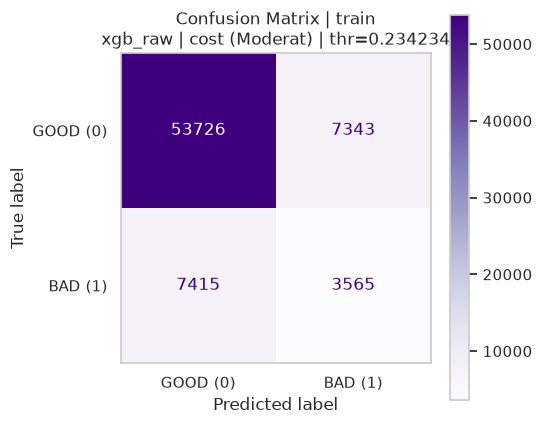


FINAL MODEL REPORT | split=valid | model=xgb_raw | threshold_objective=cost (Moderat) | threshold=0.234234

Classification Report & Confusion Matrix | valid
              precision    recall  f1-score   support

    GOOD (0)       0.88      0.87      0.87      8981
     BAD (1)       0.31      0.32      0.31      1615

    accuracy                           0.79     10596
   macro avg       0.59      0.59      0.59     10596
weighted avg       0.79      0.79      0.79     10596



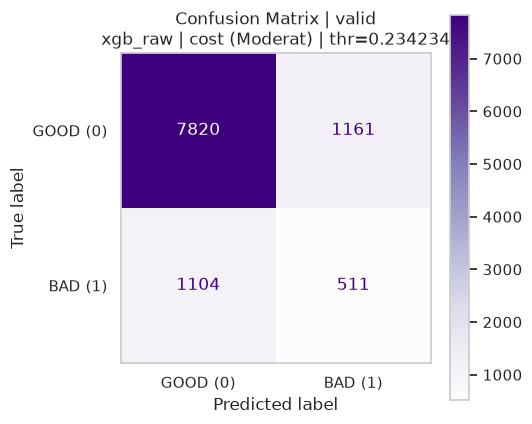


FINAL MODEL REPORT | split=test | model=xgb_raw | threshold_objective=cost (Moderat) | threshold=0.234234

Classification Report & Confusion Matrix | test
              precision    recall  f1-score   support

    GOOD (0)       0.88      0.87      0.88     19346
     BAD (1)       0.25      0.27      0.26      3135

    accuracy                           0.79     22481
   macro avg       0.57      0.57      0.57     22481
weighted avg       0.79      0.79      0.79     22481



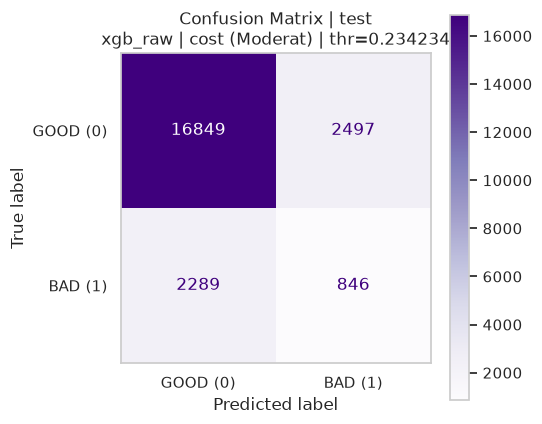

In [26]:
# =========================================================
# FINAL CONFUSION MATRICES + CLASSIFICATION REPORT
# =========================================================
logger.info(f"Generating final confusion matrices and classification reports...")

# Kita gunakan probabilitas final dari hasil Tahap B
# Pastikan Anda telah menetapkan 'winner_threshold' dari skenario atau objective pilihan Anda (misal: 'cost' atau 'moderat')
# Untuk contoh ini, mari asumsikan kita mengunci threshold berdasarkan kriteria objective 'cost' dari data valid
cost_row_valid = threshold_leaderboard[
    (threshold_leaderboard['split'] == '2_valid') & 
    (threshold_leaderboard['threshold_objective'] == 'cost')
].iloc[0]

winner_threshold = cost_row_valid['threshold_opt']
winner_threshold_objective = 'cost (Moderat)'

# =========================================================
# RECONSTRUCT TRAIN PROBABILITIES FOR FULL REPORTING
# =========================================================
# Karena di Tahap B keputusannya adalah "PERTAHANKAN RAW MODEL",
# kita bisa langsung mengekstrak probabilitas Train dari model terbaik.
try:
    # Coba prediksi langsung dari objek model terbaik (sklear/lgbm/xgb API standard)
    p_train_fit_final = best_model_obj.predict_proba(X_train_fit)[:, 1]
    logger.info("Successfully generated p_train_fit_final directly from best_model_obj.")
except Exception as e:
    # Fallback aman jika tipe data X_train_fit membutuhkan penyesuaian khusus
    logger.warning(f"Gagal memprediksi langsung: {e}. Mencoba alternatif dari dictionary.")
    # Mencari versi kunci yang tepat di dalam winner_proba_store
    p_train_fit_final = winner_proba_store[final_model_version]['train_fit']

final_splits_report = {
    'train': (y_train_fit, p_train_fit_final),
    'valid': (y_valid, p_valid_final),
    'test': (y_test, p_test_final),
}

for split_name, (y_true, y_proba) in final_splits_report.items():
    y_pred = (np.asarray(y_proba) >= winner_threshold).astype(int)

    print("\n" + "=" * 80)
    print(
        f"FINAL MODEL REPORT | split={split_name} | "
        f"model={final_model_version} | "
        f"threshold_objective={winner_threshold_objective} | "
        f"threshold={winner_threshold:.6f}"
    )
    print("=" * 80)

    from src.helpers import print_report_and_cm
    cm_df = print_report_and_cm(
        y_true, y_pred,
        f"Classification Report & Confusion Matrix | {split_name}"
    )
    
    from sklearn.metrics import ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_df.values, display_labels=['GOOD (0)', 'BAD (1)'])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(values_format='d', cmap='Purples', ax=ax)
    ax.grid(False)
    plt.title(
        f"Confusion Matrix | {split_name}\n"
        f"{final_model_version} | {winner_threshold_objective} | thr={winner_threshold:.6f}"
    )
    plt.show()

In [27]:
# =========================================================
# COMPACT BUSINESS SUMMARY
# =========================================================
logger.info(f"Creating compact business summary...")

# Summary Probabilitas (Tahap A / B) dari data leaderboard Tahap B
if 'cal_leaderboard' in locals():
    # Ambil baris performa probabilitas dari versi model yang menang
    prob_winner_summary = cal_leaderboard[cal_leaderboard['model_version'] == final_model_version].copy()
    print(f"\n=== BUSINESS SUMMARY: FINAL PROBABILITY QUALITY (VALID) ===")
    display(prob_winner_summary)

# Summary Threshold (Tahap C)
threshold_winner_summary = threshold_leaderboard[
    threshold_leaderboard['threshold_objective'] == 'cost'
].copy()

print(f"\n=== BUSINESS SUMMARY: FINAL THRESHOLD PERFORMANCE ===")
display(threshold_winner_summary)

print(f"\n=== OVERALL PIPELINE WINNER ===")
print(f"Base Model Name          : {best_model_name}")
print(f"Final Calibrated Version : {final_model_version}")
print(f"Threshold Objective      : {winner_threshold_objective}")
print(f"Operational Threshold    : {winner_threshold:.6f}")

logger.info(f"=== END CALIBRATION & THRESHOLDING PIPELINE ===")

2026-07-19 05:03:18,213 - INFO - Creating compact business summary...

=== BUSINESS SUMMARY: FINAL PROBABILITY QUALITY (VALID) ===


,model_version,roc_auc,pr_auc,log_loss,brier_score,gini,ks_statistic
0,xgb_raw,0.678778,0.270626,0.400156,0.122176,0.357555,0.266551



=== BUSINESS SUMMARY: FINAL THRESHOLD PERFORMANCE ===


,model,split,threshold_objective,threshold_opt,threshold_objective_value,Balanced_Accuracy,MCC,Precision_Bad,Recall_Bad,F1_Bad,Specificity,NPV,FPR,FNR,Predicted_Bad_Rate,TN,FP,FN,TP
4,xgb_raw,2_valid,cost,0.234234,1.155408e+06,0.593568,0.184505,0.305622,0.316409,0.310922,0.870727,0.876289,0.129273,0.683591,0.157795,7820,1161,1104,511
5,xgb_raw,3_test,cost,0.234234,NaN,0.570393,0.137075,0.253066,0.269856,0.261192,0.870929,0.880395,0.129071,0.730144,0.148703,16849,2497,2289,846



=== OVERALL PIPELINE WINNER ===
Base Model Name          : xgb_raw
Final Calibrated Version : xgb_raw
Threshold Objective      : cost (Moderat)
Operational Threshold    : 0.234234
2026-07-19 05:03:18,248 - INFO - === END CALIBRATION & THRESHOLDING PIPELINE ===


In [28]:
# ================================================================
# POST-PIPELINE SETUP (FOR SHAP, KS, COST CURVES)
# ================================================================
# Kita mengisolasi base model dari string final_model_version.
# Jika final_model_version adalah 'lgbm_raw_cal_isotonic', kita potong 
# bagian kalibrasinya untuk mendapatkan 'lgbm_raw' asli (wajib untuk TreeSHAP).

logger.info(f"Preparing Post-Pipeline artifacts (SHAP, KS, Cost)...")

# Membedah nama base model secara aman dari final_model_version
if "_cal_" in final_model_version:
    # Jika terkalibrasi (misal: 'lgbm_raw_cal_isotonic'), ambil sisi kirinya saja
    shap_base_model_key = final_model_version.split("_cal_")[0]
else:
    # Jika tidak ada komponen kalibrasi (misal: 'lgbm_raw'), maka inilah base model aslinya
    shap_base_model_key = final_model_version

# Memastikan model dasar untuk SHAP memang ada di dictionary asli (my_fitted_models)
if shap_base_model_key in my_fitted_models:
    shap_base_model = my_fitted_models[shap_base_model_key]
    logger.info(f"SHAP Base Model safely mapped to: {shap_base_model_key} (Type: {type(shap_base_model).__name__})")
else:
    logger.warning(f"Could not map {final_model_version} strictly back to a base model key. Falling back to the selected winner.")
    shap_base_model = best_model_obj
    shap_base_model_key = best_model_name

# Menyimpan probabilitas pemenang ke variabel yang dibutuhkan di post-pipeline
proba_valid_winner = p_valid_final
proba_test_winner = p_test_final

logger.info(f"Post-Pipeline Setup complete. Ready for SHAP analysis.")

2026-07-19 05:03:18,253 - INFO - Preparing Post-Pipeline artifacts (SHAP, KS, Cost)...
2026-07-19 05:03:18,255 - INFO - SHAP Base Model safely mapped to: xgb_raw (Type: XGBClassifier)
2026-07-19 05:03:18,255 - INFO - Post-Pipeline Setup complete. Ready for SHAP analysis.


<br>

---
# **Kolmogorov-Smirnov (KS) Statistics**:

=== KS STATISTICS (WINNER MODEL: FINAL THRESHOLD ALIGNMENT) ===


,Dataset,KS Statistic,KS (%),KS Threshold,Interpretasi
0,Training (train_fit),0.2852,28.52,0.1505,adequate
1,Validation,0.2666,26.66,0.1384,adequate
2,Test,0.2180,21.80,0.1403,adequate


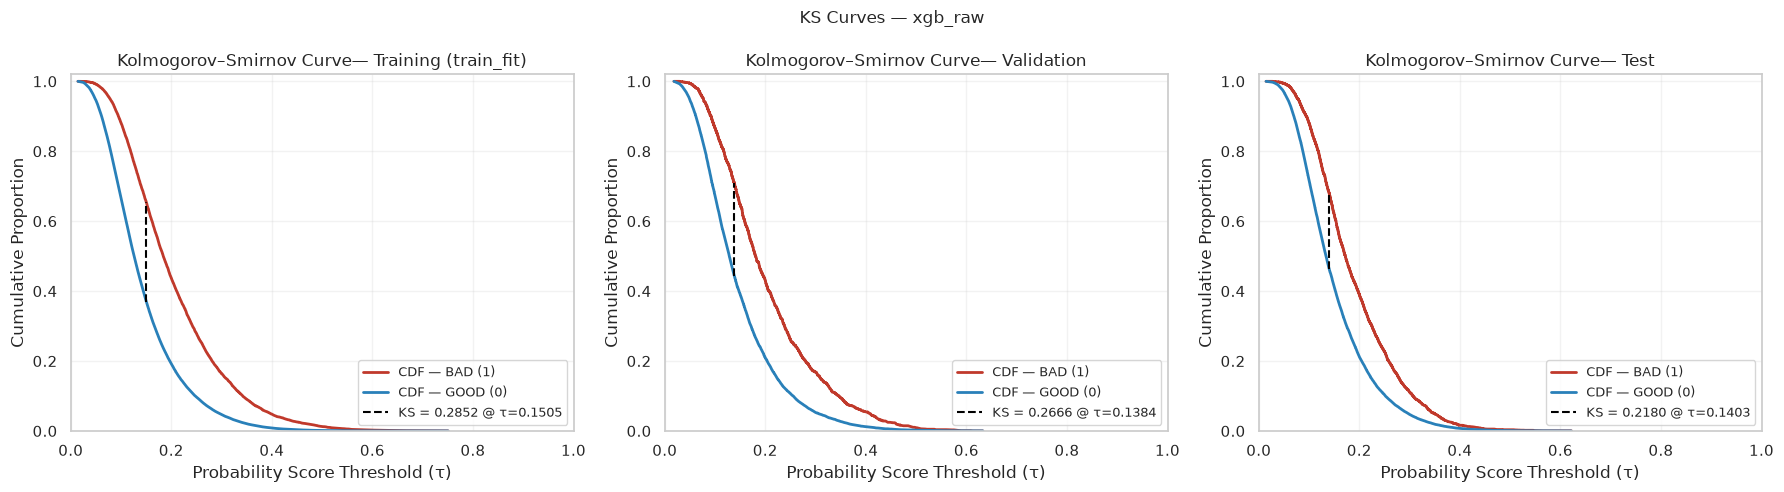

In [29]:
"""
Implementation of Kolmogorov-Smirnov (KS) Statistics as a Complementary Diagnostic
for the Evaluation of Binary Credit Risk Classification Models.

Theoretical context:
    KS = max_tau | F_BAD(tau) - F_GOOD(tau) |
       = max_tau | TPR(tau) - FPR(tau) |

Mathematically KS is identical to the maximum value of the Youden index (KS = max J),
but is reported as a single scalar that summarizes the overall separation capacity of the model,
accompanied by a visualization of two cumulative CDF curves of the prediction scores for each class (GOOD vs BAD).

Industry interpretation convention (Siddiqi, 2017, Credit Risk Scorecards):
    KS < 20%   : Weak discrimination
    20% - 40%  : Adequate discrimination
    > 40%      : Strong discrimination
"""

if __name__ == "__main__":
    
    datasets = {
        'Training (train_fit)' : (y_train_fit, p_train_fit_final),
        'Validation'           : (y_valid, proba_valid_winner),
        'Test'                 : (y_test,  proba_test_winner),
    }
    print(f"=== KS STATISTICS (WINNER MODEL: FINAL THRESHOLD ALIGNMENT) ===")
    from src.ks_statistic_evaluation import ks_report_table, plot_ks_curve
    ks_table = ks_report_table(datasets)
    display(ks_table)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, (y_t, p)) in zip(axes, datasets.items()):
        plot_ks_curve(y_t, p, dataset_name=name, ax=ax)
    plt.suptitle(f"KS Curves — {final_model_version}", fontsize=12)
    plt.tight_layout()
    plt.savefig("ks_curves_all_partitions_TB.png", dpi=150)
    plt.show()
    pass

<br>

---
# **Expected Cost Function**:

2026-07-19 05:03:19,244 - INFO - ===== Estimasi Komponen Biaya =====
2026-07-19 05:03:19,251 - INFO - C_FN (kerugian default) : 8250000.0000
2026-07-19 05:03:19,252 - INFO - C_FP (opportunity cost) : 2700000.0000
2026-07-19 05:03:19,253 - INFO - Rasio C_FN/C_FP         : 3.0556
2026-07-19 05:03:19,293 - INFO - Tau optimal-biaya       : 0.2342
2026-07-19 05:03:19,294 - INFO - Recall BAD di tau optimal-biaya : 0.3164

2026-07-19 05:03:19,327 - INFO - ===== Perbandingan Ambang Threshold =====
2026-07-19 05:03:19,328 - INFO - Tau optimal-biaya : 0.2342
2026-07-19 05:03:19,329 - INFO - Tau Youden's J    : 0.1384
2026-07-19 05:03:19,329 - INFO - Tau F1 maksimal   : 0.1537
2026-07-19 05:03:19,330 - INFO - Rasio C_FN/C_FP   : 3.0600
2026-07-19 05:03:19,330 - INFO - Interpretasi: Dengan rasio C_FN/C_FP = 3.0556, ambang optimal-biaya berada di atas ambang Youden -- selisih 0.0958 pada skala probabilitas.


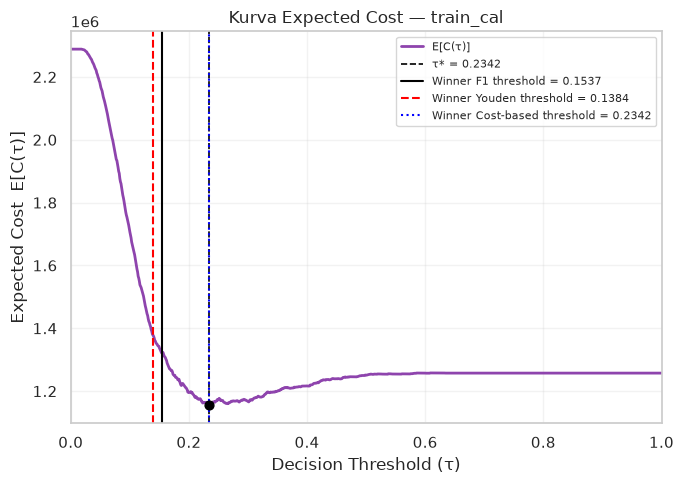

In [30]:
"""
Implementasi Fungsi Expected Cost untuk Penentuan Ambang Keputusan Optimal-Biaya
pada Model Klasifikasi Risiko Kredit Biner.

Kerangka teoretis (Elkan, 2001; BCBS, 2006 untuk estimasi komponen LGD/EAD):

    E[C(tau)] = C_FN * P(y=1) * P(yhat=0 | y=1, tau)
              + C_FP * P(y=0) * P(yhat=1 | y=0, tau)

    di mana:
        P(yhat=0 | y=1, tau) = 1 - Recall_BAD(tau)      [False Negative Rate]
        P(yhat=1 | y=0, tau) = FPR(tau)                  [False Positive Rate]

    C_FN (biaya false negative, memberi pinjaman pada peminjam yang gagal bayar)
        didekomposisi sebagai:  C_FN ≈ EAD * LGD

    C_FP (biaya false positive, menolak peminjam yang sesungguhnya baik)
        didekomposisi sebagai opportunity cost margin bunga marjinal:
        C_FP ≈ EAD * spread_bunga * durasi_pinjaman

    tau* = argmin_tau E[C(tau)]

Catatan epistemik penting:
    C_FN dan C_FP di sini adalah ESTIMASI PORTOFOLIO-LEVEL, bukan kepastian
    per-individu. Modul ini menyediakan dua mode: (a) biaya skalar tetap
    (rasio C_FN/C_FP konstan di seluruh observasi), dan (b) biaya per-observasi
    bila EAD bervariasi antar peminjam (mis. plafon pinjaman berbeda) --
    mode (b) lebih realistis untuk portofolio kredit konsumen heterogen.
"""

if __name__ == "__main__":
    # --- Scalar mode: portfolio mean estimate ---
    # Misal: EAD rata-rata Rp 15.000.000, LGD historis 55%,
    # For example: Average EAD Rp. 15,000,000, historical LGD 55%,
    # interest spread 9%/year, average loan duration 2 years.
    from src.expected_cost_threshold import (
    estimate_cost_components, expected_cost_curve_scalar, 
    compare_threshold_criteria, plot_expected_cost_curve)
    
    components = estimate_cost_components(
        ead=15_000_000,
        lgd=0.55,
        interest_spread=0.09,
        loan_duration_years=2.0,
    )
    def print_cost_report(components):
        logger.info(f"===== Estimasi Komponen Biaya =====")
        logger.info(f"C_FN (kerugian default) : {components['C_FN']:.4f}")
        logger.info(f"C_FP (opportunity cost) : {components['C_FP']:.4f}")
        logger.info(f"Rasio C_FN/C_FP         : {components['ratio_CFN_CFP']:.4f}")

    print_cost_report(components)
    # C_FN = 15jt * 0.55 = 8.25jt
    # C_FP = 15jt * 0.09 * 2 = 2.7jt
    # rasio C_FN/C_FP ≈ 3.06
    
    cost_result_winner = expected_cost_curve_scalar(
        y_valid, proba_valid_winner,
        c_fn=components['C_FN'], c_fp=components['C_FP']
    )
    logger.info(f"Tau optimal-biaya       : {cost_result_winner['optimal_threshold']:.4f}")
    logger.info(f"Recall BAD di tau optimal-biaya : {cost_result_winner['optimal_recall_bad']:.4f}\n")
    
    comparison = compare_threshold_criteria(
        y_valid, proba_valid_winner, components['C_FN'], components['C_FP']
    )
    logger.info(f"===== Perbandingan Ambang Threshold =====")
    logger.info(f"Tau optimal-biaya : {comparison['tau_expected_cost']:.4f}")
    logger.info(f"Tau Youden's J    : {comparison['tau_youden_j']:.4f}")
    logger.info(f"Tau F1 maksimal   : {comparison['tau_f1_maximal']:.4f}")
    logger.info(f"Rasio C_FN/C_FP   : {comparison['cost_ratio_CFN_CFP']:.4f}")
    logger.info(f"Interpretasi: {comparison['interpretasi']}")

    thres = threshold_leaderboard[threshold_leaderboard['split'] == '2_valid'].to_dict('records')
    
    # Get `threshold_opt` for objective F1 & Youden J from Stage 2
    f1_row= next(row for row in thres if row['threshold_objective'] == 'f1')
    youden_row = next(row for row in thres if row['threshold_objective'] == 'youden')
    cost_row = next(row for row in thres if row['threshold_objective'] == 'cost')
    
    f1_threshold_opt = f1_row['threshold_opt']
    ydn_threshold_opt = youden_row['threshold_opt']
    cost_threshold_opt = cost_row['threshold_opt']
    
    ax_cost = plot_expected_cost_curve(cost_result_winner, dataset_name='train_cal')
    # Add vertical markers for F1/Youden (which are identical)
    ax_cost.axvline(
        f1_threshold_opt, 
        color='black', linestyle='-', linewidth=1.5,
        label=f"Winner F1 threshold = {f1_threshold_opt:.4f}"
    )
    ax_cost.axvline(
        ydn_threshold_opt,
        color='red', linestyle='--', linewidth=1.5,
        label=f"Winner Youden threshold = {ydn_threshold_opt:.4f}"
    )
    ax_cost.axvline(
        cost_threshold_opt,
        color='blue', linestyle=':', linewidth=1.5,
        label=f"Winner Cost-based threshold = {cost_threshold_opt:.4f}"
    )
    ax_cost.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("expected_cost_curve_valid_TB.png", dpi=150)
    plt.show()
    pass

<br>

---
# **SHAP (SHapley Additive exPlanations)**:

2026-07-19 05:03:24,043 - INFO - === SHAP AXIOM CHECK ===


{'max_absolute_difference': 3.5762786865234375e-06,
 'axiom_satisfied': True,
 'interpretation': 'Aksioma efficiency terverifikasi -- dekomposisi SHAP additive secara eksak terhadap output margin model.'}

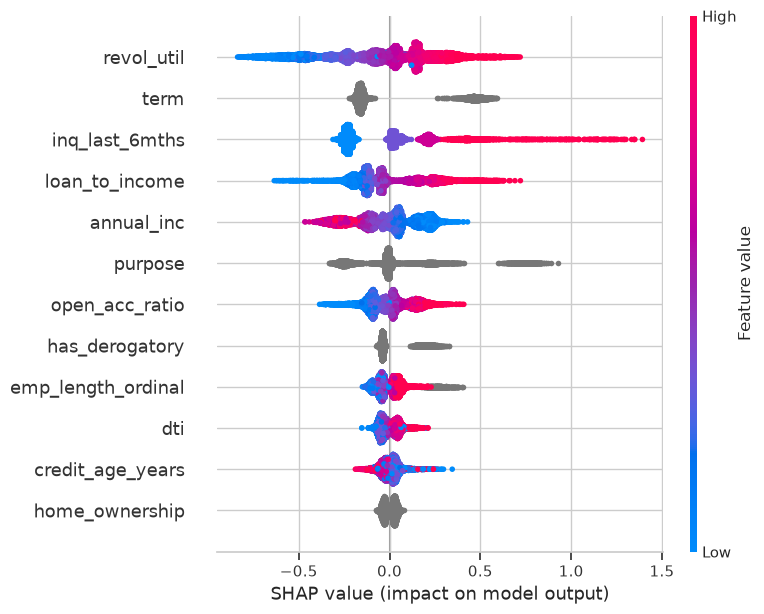

2026-07-19 05:03:25,331 - INFO - === SHAP GLOBAL IMPORTANCE (TOP 12) ===


,feature,mean_abs_shap,rank
0,revol_util,0.239056,1
1,term,0.231880,2
2,inq_last_6mths,0.203498,3
3,loan_to_income,0.159897,4
4,annual_inc,0.141453,5
5,purpose,0.123859,6
6,open_acc_ratio,0.095397,7
7,has_derogatory,0.065330,8
8,emp_length_ordinal,0.060337,9
9,dti,0.043185,10


2026-07-19 05:03:25,341 - INFO - === SHAP vs GAIN IMPORTANCE COMPARISON ===


'Korelasi peringkat Spearman = 0.867. Konkordansi tinggi antar dua metode -- temuan saling menguatkan.'

,feature,rank_shap,rank_gain
0,revol_util,1,5
1,term,2,1
2,inq_last_6mths,3,2
3,loan_to_income,4,3
4,annual_inc,5,6
5,purpose,6,4
6,open_acc_ratio,7,9
7,has_derogatory,8,7
8,emp_length_ordinal,9,8
9,dti,10,12


<Figure size 700x500 with 0 Axes>

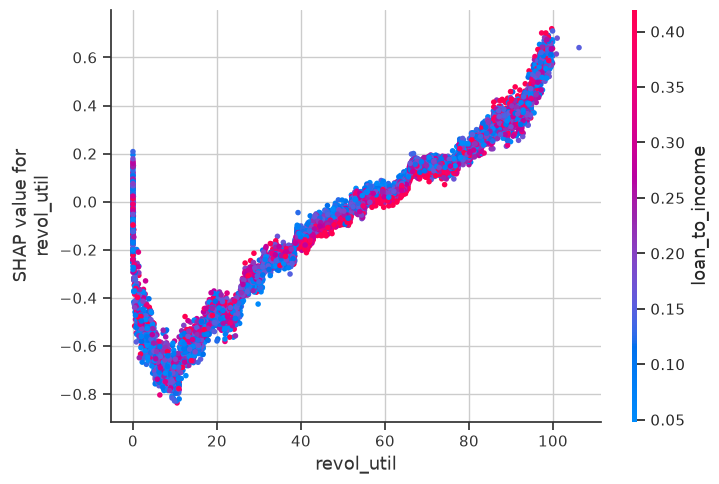

'Relasi monoton increasing terkonfirmasi (rho=0.971), sesuai ekspektasi domain. '

2026-07-19 05:03:25,717 - INFO - === LOCAL EXPLANATION | Highest risk observation (idx=5102) ===


,feature,feature_value,shap_value,abs_shap_value,direction
0,purpose,small_business,0.694459,0.694459,menaikkan risiko (mendorong ke BAD)
1,term,60_months,0.529446,0.529446,menaikkan risiko (mendorong ke BAD)
2,revol_util,94.0,0.414528,0.414528,menaikkan risiko (mendorong ke BAD)
3,loan_to_income,0.39881,0.361348,0.361348,menaikkan risiko (mendorong ke BAD)
4,annual_inc,42000.0,0.114648,0.114648,menaikkan risiko (mendorong ke BAD)
5,emp_length_ordinal,10.0,0.079152,0.079152,menaikkan risiko (mendorong ke BAD)
6,open_acc_ratio,0.352941,-0.059307,0.059307,menurunkan risiko (mendorong ke GOOD)
7,inq_last_6mths,1.0,0.047024,0.047024,menaikkan risiko (mendorong ke BAD)
8,home_ownership,RENT,0.045539,0.045539,menaikkan risiko (mendorong ke BAD)
9,credit_age_years,11.416667,0.042644,0.042644,menaikkan risiko (mendorong ke BAD)


2026-07-19 05:03:25,724 - INFO - Final probability: 0.6328
2026-07-19 05:03:25,726 - INFO - Decision (tau=0.2286): REJECT (BAD)


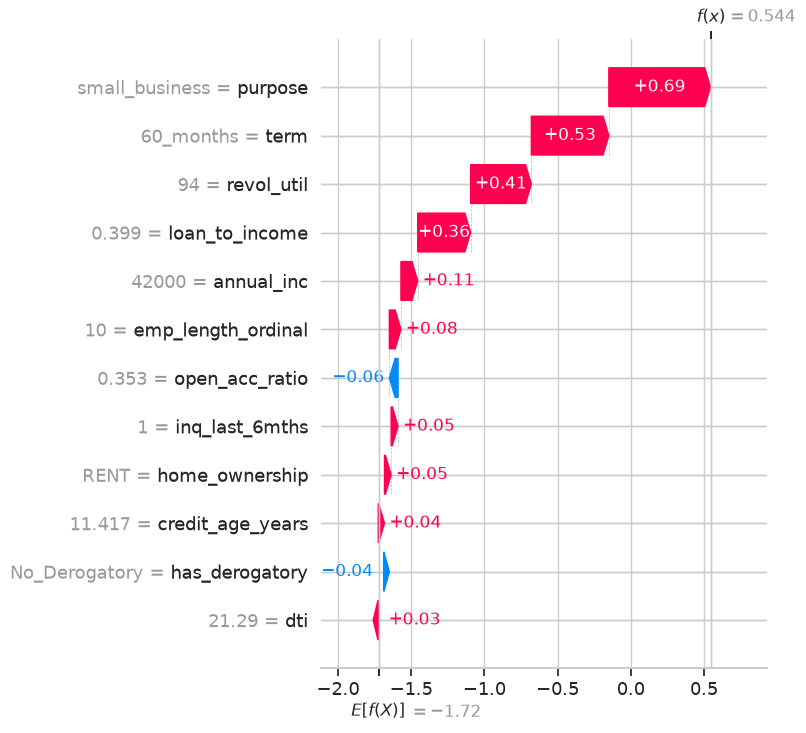

In [32]:
import shap

"""
Implementation of SHAP (SHapley Additive exPlanations)

Reference:
    Lundberg, S. M., & Lee, S.-I. (2017). A Unified Approach to
        Interpreting Model Predictions. NeurIPS.
    Lundberg, S. M. et al. (2020). 
        From Local Explanations to Global Understanding with Explainable AI for Trees. Nature Machine Intelligence.

Module coverage:
    1. Computing Shapley values via TreeSHAP (exact, O(T*L*D^2))
    2. Global diagnostics     -- summary plot (feature importance & direction)
    3. Relational diagnostics -- dependence plot (monotonicity vs. domain)
    4. Local explanation      -- waterfall/force plot per-individual, for "adverse action notice" purposes
    5. Axiomatic validation   -- numerical checking of efficiency properties
    6. Consistency audit      -- comparison of SHAP importance vs gain-based feature_importance built-in Tree-based Models

Important note regarding output scale:
    Untuk objective="binary:logistic", TreeSHAP secara default mengembalikan kontribusi pada skala LOG-ODDS (sebelum sigmoid), 
    BUKAN skala probabilitas langsung -- konsekuensi dari additivity aksiomatik (Bagian "efficiency") yang hanya berlaku linear 
    pada skala margin model, bukan pada skala probabilitas yang non-linear. Interpretasi pada skala probabilitas memerlukan 
    transformasi non-linear tambahan (lihat shap.Explanation dengan link="logit" pada beberapa plot, atau interpretasi manual).
"""

if __name__ == "__main__": # Running SHAP Interpretation...
    
    from src.shap_interpretability import (
    compute_shap_values, validate_efficiency_axiom, 
    plot_global_importance, get_global_importance_table,
    compare_shap_vs_gain_importance, plot_dependence,
    check_monotonicity, explain_individual_prediction,
    plot_individual_waterfall
    )
    
    explanation = compute_shap_values(shap_base_model, X_valid)
    
    # 1. Axiomatic validation (MUST be run once as a sanity check)
    axiom_check = validate_efficiency_axiom(explanation, shap_base_model, X_valid)
    logger.info(f"=== SHAP AXIOM CHECK ===")
    display(axiom_check)
    
    # 2. Global diagnostics
    fig1 = plot_global_importance(explanation, max_display=12)
    fig1.savefig("shap_summary_global.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    importance_table = get_global_importance_table(
        explanation, X_valid.columns.tolist()
    )
    logger.info(f"=== SHAP GLOBAL IMPORTANCE (TOP 12) ===")
    display(importance_table.head(12))
    
    comparison_gain = compare_shap_vs_gain_importance(
        explanation, shap_base_model, X_valid.columns.tolist()
    )
    logger.info(f"=== SHAP vs GAIN IMPORTANCE COMPARISON ===")
    display(comparison_gain['interpretation'])
    display(comparison_gain['comparison_table'][['feature','rank_shap','rank_gain']].head(12))
    
    # 3. Relational diagnostics -- example for revol_util feature
    fig2 = plot_dependence(explanation, 'revol_util')
    fig2.savefig('shap_dependence_revol_util.png', dpi=150, bbox_inches='tight')
    plt.show()
    mono_check = check_monotonicity(
        explanation, 'revol_util', expected_direction="increasing"
    )
    display(mono_check['interpretation'])
    
    # 4. Local explanation -- example for the observation with the highest risk score
    proba_valid_arr = np.asarray(proba_valid_winner)
    highest_risk_idx = int(np.argmax(proba_valid_arr))
    
    local_explanation = explain_individual_prediction(
        explanation, highest_risk_idx, top_n=12
    )
    logger.info(f"=== LOCAL EXPLANATION | Highest risk observation (idx={highest_risk_idx}) ===")
    display(local_explanation['table'])
    logger.info(f"Final probability: {local_explanation['final_probability']:.4f}")
    logger.info(f"Decision (tau=0.2286): {'REJECT (BAD)' if local_explanation['final_probability'] >= winner_threshold else 'APPROVE (GOOD)'}")
    
    fig3 = plot_individual_waterfall(explanation, highest_risk_idx)
    fig3.savefig('shap_waterfall_individual.png', dpi=150, bbox_inches='tight')
    plt.show()
    pass